<a href="https://colab.research.google.com/github/amien1410/colab-notebooks/blob/main/AnimalImagesClassification_EfficientNetB3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title Install Kaggle modules and download the dataset

from google.colab import drive
drive.mount('/content/drive')

!pip install kaggle
import os
os.environ['KAGGLE_CONFIG_DIR'] = '/content/drive/MyDrive/kaggle'
!kaggle datasets download -d alessiocorrado99/animals10
!unzip -q "/content/animals10.zip"

Mounted at /content/drive
Dataset URL: https://www.kaggle.com/datasets/alessiocorrado99/animals10
License(s): GPL-2.0
 98% 575M/586M [00:01<00:00, 286MB/s]
100% 586M/586M [00:01<00:00, 395MB/s]


In [2]:
binatang = {
    "cane": "anjing",
    "cavallo": "kuda",
    "elefante": "gajah",
    "farfalla": "kupu-kupu",
    "gallina": "ayam",
    "gatto": "kucing",
    "mucca": "sapi",
    "pecora": "domba",
    "scoiattolo": "tupai",
    "dog": "cane",
    "horse": "kuda",
    "elephant": "gajah",
    "butterfly": "kupu-kupu",
    "chicken": "ayam",
    "cat": "kucing",
    "cow": "sapi",
    "spider": "ragno",
    "squirrel": "tupai",
    "ragno": "laba-laba"
}

In [3]:
import os, random
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers, Input, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import tensorflow.keras.backend as K

# ===============================
# ✅ TPU Initialization
# ===============================
print("🔍 Checking for TPU...")
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    print("✅ TPU detected:", tpu.master())
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
except ValueError:
    print("⚠️ TPU not found, using default strategy (CPU/GPU)")
    strategy = tf.distribute.get_strategy()

# ===============================
# ✅ Mixed Precision (bfloat16 for TPU)
# ===============================
print("⚡ Enabling mixed precision (bfloat16) for TPU optimization...")
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy("mixed_bfloat16")
mixed_precision.set_global_policy(policy)

# ===============================
# ✅ Seed for Reproducibility
# ===============================
def seed_all(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

seed_all(42)
print("✅ Random seeds set for reproducibility")

# ===============================
# ✅ Dataset Path & Parameters
# ===============================
DATASET_PATH = "/content/raw-img"
TARGET_SIZE = (224, 224)
BATCH_SIZE = 64 * strategy.num_replicas_in_sync
AUTO = tf.data.AUTOTUNE
print(f"📂 Dataset Path: {DATASET_PATH}")
print(f"📌 Using batch size: {BATCH_SIZE}")

# ===============================
# ✅ Build Image DataFrame
# ===============================
def build_image_df(dataset_path):
    print("📄 Scanning dataset for image files...")
    image_dir = Path(dataset_path)
    files = list(image_dir.rglob("*.jpg")) + list(image_dir.rglob("*.jpeg")) + list(image_dir.rglob("*.png"))
    labels = [p.parent.name for p in files]
    print(f"✅ Found {len(files)} images across {len(set(labels))} classes")
    return pd.DataFrame({"filepath": [str(p) for p in files], "label": labels})

df = build_image_df(DATASET_PATH)
labels_list = sorted(df.label.unique())
label2id = {l: i for i, l in enumerate(labels_list)}
df["label_id"] = df.label.map(label2id)
print(f"📌 Classes: {labels_list}")

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df.label_id, random_state=42)
print(f"✅ Split dataset: {len(train_df)} train / {len(test_df)} test")

# ===============================
# ✅ TF Data Pipeline
# ===============================
print("⚙️ Preparing tf.data pipelines...")

def decode_img(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, TARGET_SIZE)
    img = tf.keras.applications.efficientnet_v2.preprocess_input(img)
    return img, label

def augment_img(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_brightness(img, 0.1)
    return img, label

def make_dataset(paths, labels, training=True):
    print(f"🔄 Building {'training' if training else 'validation'} dataset...")
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(decode_img, num_parallel_calls=AUTO)
    if training:
        ds = ds.map(augment_img, num_parallel_calls=AUTO)
        ds = ds.shuffle(1024)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTO)
    print(f"✅ {'Training' if training else 'Validation'} dataset ready")
    return ds

train_ds = make_dataset(train_df.filepath.values, train_df.label_id.values, training=True)
val_ds   = make_dataset(test_df.filepath.values, test_df.label_id.values, training=False)

# ===============================
# ✅ Custom F1 Metric
# ===============================
print("➕ Adding custom F1 metric...")
def f1_score(y_true, y_pred):
    # Convert sparse labels (int64) to one-hot with same depth as y_pred
    y_true = tf.cast(y_true, tf.int32)
    y_true = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
    y_pred = K.round(y_pred)

    tp = K.sum(K.cast(y_true * y_pred, "float32"), axis=0)
    fp = K.sum(K.cast((1 - y_true) * y_pred, "float32"), axis=0)
    fn = K.sum(K.cast(y_true * (1 - y_pred), "float32"), axis=0)

    precision = tp / (tp + fp + K.epsilon())
    recall = tp / (tp + fn + K.epsilon())
    f1 = 2 * precision * recall / (precision + recall + K.epsilon())
    return K.mean(f1)

# ===============================
# ✅ Model Definition
# ===============================
print("🧠 Building EfficientNetV2-S model under TPU strategy...")
with strategy.scope():
    base_model = tf.keras.applications.EfficientNetV2S(
        include_top=False, weights="imagenet", input_shape=(224,224,3), pooling="avg"
    )
    base_model.trainable = False

    inputs = Input(shape=(224,224,3))
    x = base_model(inputs, training=False)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    outputs = layers.Dense(len(labels_list), activation="softmax", dtype="float32")(x)

    model = Model(inputs, outputs)

    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy", f1_score])
print("✅ Model compiled successfully")

# ===============================
# ✅ Callbacks
# ===============================
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint("best_tpu_efficientnetv2s.h5", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-6)
]
print("✅ Callbacks configured")

# ===============================
# ✅ Phase 1 Training: Feature Extraction
# ===============================
print("🚀 Starting Phase 1: Feature Extraction Training...")
history = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=callbacks)
print("✅ Phase 1 complete")

# ===============================
# ✅ Phase 2 Training: Fine-Tuning
# ===============================
print("🔧 Unfreezing top layers for fine-tuning...")
with strategy.scope():
    base_model.trainable = True
    for layer in base_model.layers[:-40]:
        layer.trainable = False

    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy", f1_score])
print("🚀 Starting Phase 2: Fine-Tuning...")
history_ft = model.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=callbacks)
print("✅ Phase 2 complete")

# ===============================
# ✅ Evaluation
# ===============================
print("📊 Evaluating on validation set...")
loss, acc, f1 = model.evaluate(val_ds)
print(f"✅ Final Results → Accuracy: {acc:.4f} | F1: {f1:.4f}")

# ===============================
# ✅ Save Model
# ===============================
model.save("efficientnetv2_tpu_final.h5")
print("💾 Model saved as efficientnetv2_tpu_final.h5")


🔍 Checking for TPU...
⚠️ TPU not found, using default strategy (CPU/GPU)
⚡ Enabling mixed precision (bfloat16) for TPU optimization...
✅ Random seeds set for reproducibility
📂 Dataset Path: /content/raw-img
📌 Using batch size: 64
📄 Scanning dataset for image files...
✅ Found 26179 images across 10 classes
📌 Classes: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
✅ Split dataset: 20943 train / 5236 test
⚙️ Preparing tf.data pipelines...
🔄 Building training dataset...
✅ Training dataset ready
🔄 Building validation dataset...
✅ Validation dataset ready
➕ Adding custom F1 metric...
🧠 Building EfficientNetV2-S model under TPU strategy...
82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
✅ Model compiled successfully
✅ Callbacks configured
🚀 Starting Phase 1: Feature Extraction Training...
Epoch 1/20
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.7468 - f1_score: 0.7022 - loss: 0.8446

328/328 ━━━━━━━━━━━━━━━━━━━━ 188s 399ms/step - accuracy: 0.7472 - f1_score: 0.7027 - loss: 0.8432 - val_accuracy: 0.9729 - val_f1_score: 0.9575 - val_loss: 0.1112 - learning_rate: 1.0000e-04
Epoch 2/20
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9580 - f1_score: 0.9384 - loss: 0.1512

328/328 ━━━━━━━━━━━━━━━━━━━━ 122s 243ms/step - accuracy: 0.9580 - f1_score: 0.9384 - loss: 0.1512 - val_accuracy: 0.9784 - val_f1_score: 0.9622 - val_loss: 0.0784 - learning_rate: 1.0000e-04
Epoch 3/20
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.9675 - f1_score: 0.9503 - loss: 0.1203

328/328 ━━━━━━━━━━━━━━━━━━━━ 73s 217ms/step - accuracy: 0.9675 - f1_score: 0.9503 - loss: 0.1203 - val_accuracy: 0.9820 - val_f1_score: 0.9670 - val_loss: 0.0714 - learning_rate: 1.0000e-04
Epoch 4/20
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9717 - f1_score: 0.9595 - loss: 0.1075

328/328 ━━━━━━━━━━━━━━━━━━━━ 81s 242ms/step - accuracy: 0.9717 - f1_score: 0.9595 - loss: 0.1075 - val_accuracy: 0.9809 - val_f1_score: 0.9667 - val_loss: 0.0686 - learning_rate: 1.0000e-04
Epoch 5/20
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.9734 - f1_score: 0.9617 - loss: 0.1003

...

328/328 ━━━━━━━━━━━━━━━━━━━━ 191s 384ms/step - accuracy: 0.9824 - f1_score: 0.9742 - loss: 0.0603 - val_accuracy: 0.9862 - val_f1_score: 0.9743 - val_loss: 0.0578 - learning_rate: 1.0000e-04
Epoch 2/30
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.9875 - f1_score: 0.9803 - loss: 0.0403

328/328 ━━━━━━━━━━━━━━━━━━━━ 131s 265ms/step - accuracy: 0.9875 - f1_score: 0.9803 - loss: 0.0403 - val_accuracy: 0.9866 - val_f1_score: 0.9749 - val_loss: 0.0558 - learning_rate: 1.0000e-04
Epoch 3/30
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9911 - f1_score: 0.9810 - loss: 0.0305

328/328 ━━━━━━━━━━━━━━━━━━━━ 81s 242ms/step - accuracy: 0.9911 - f1_score: 0.9810 - loss: 0.0305 - val_accuracy: 0.9864 - val_f1_score: 0.9743 - val_loss: 0.0542 - learning_rate: 1.0000e-04
Epoch 4/30
328/328 ━━━━━━━━━━━━━━━━━━━━ 80s 236ms/step - accuracy: 0.9913 - f1_score: 0.9825 - loss: 0.0258 - val_accuracy: 0.9876 - val_f1_score: 0.9770 - val_loss: 0.0575 - learning_rate: 1.0000e-04
Epoch 5/30
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.9925 - f1_score: 0.9823 - loss: 0.0227

328/328 ━━━━━━━━━━━━━━━━━━━━ 87s 262ms/step - accuracy: 0.9925 - f1_score: 0.9823 - loss: 0.0227 - val_accuracy: 0.9866 - val_f1_score: 0.9764 - val_loss: 0.0539 - learning_rate: 1.0000e-04
Epoch 6/30
328/328 ━━━━━━━━━━━━━━━━━━━━ 133s 235ms/step - accuracy: 0.9954 - f1_score: 0.9862 - loss: 0.0179 - val_accuracy: 0.9868 - val_f1_score: 0.9762 - val_loss: 0.0568 - learning_rate: 1.0000e-04
Epoch 7/30
328/328 ━━━━━━━━━━━━━━━━━━━━ 90s 259ms/step - accuracy: 0.9945 - f1_score: 0.9877 - loss: 0.0175 - val_accuracy: 0.9876 - val_f1_score: 0.9772 - val_loss: 0.0577 - learning_rate: 1.0000e-04
Epoch 8/30
328/328 ━━━━━━━━━━━━━━━━━━━━ 87s 260ms/step - accuracy: 0.9963 - f1_score: 0.9868 - loss: 0.0125 - val_accuracy: 0.9876 - val_f1_score: 0.9766 - val_loss: 0.0566 - learning_rate: 1.0000e-04
Epoch 9/30
328/328 ━━━━━━━━━━━━━━━━━━━━ 142s 261ms/step - accuracy: 0.9977 - f1_score: 0.9890 - loss: 0.0091 - val_accuracy: 0.9874 - val_f1_score: 0.9764 - val_loss: 0.0561 - learning_rate: 3.0000e-05
Epoc

✅ Final Results → Accuracy: 0.9866 | F1: 0.9764
💾 Model saved as efficientnetv2_tpu_final.h5


/tmp/ipython-input-2460688536.py:38: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


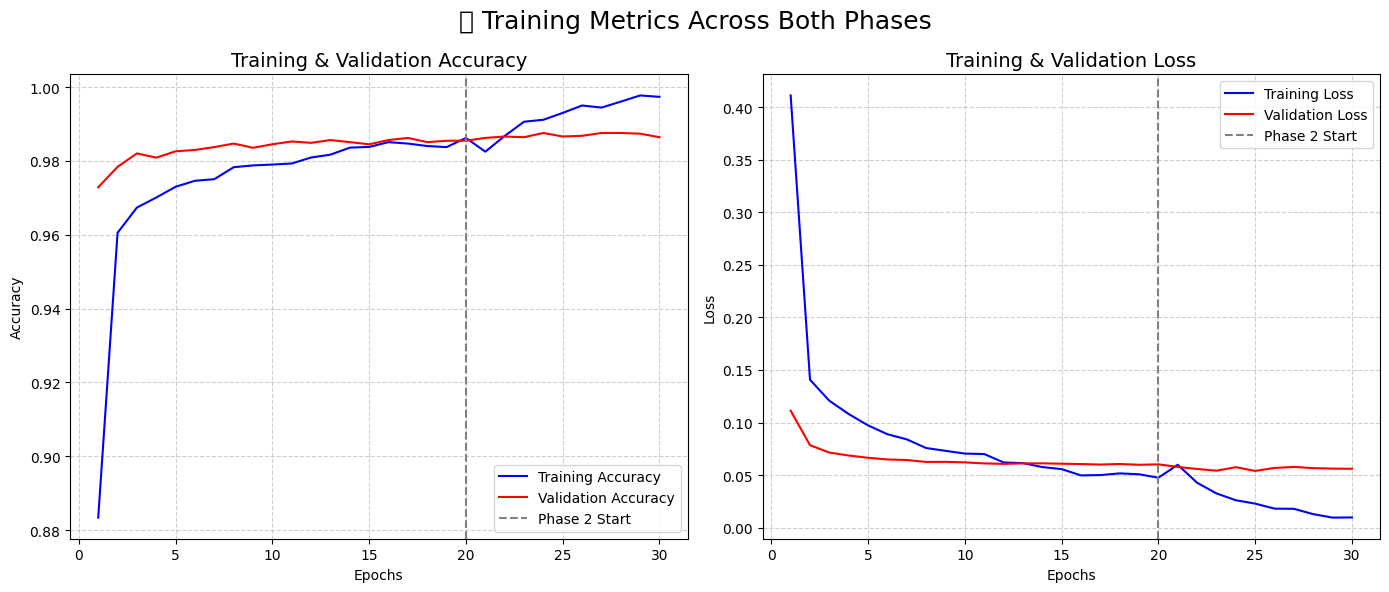

In [5]:
import matplotlib.pyplot as plt

def plot_training_history(history, history_ft):
    # ✅ Combine metrics from both phases
    acc = history.history['accuracy'] + history_ft.history['accuracy']
    val_acc = history.history['val_accuracy'] + history_ft.history['val_accuracy']
    loss = history.history['loss'] + history_ft.history['loss']
    val_loss = history.history['val_loss'] + history_ft.history['val_loss']

    epochs = range(1, len(acc) + 1)
    phase1_end = len(history.history['accuracy'])  # mark where phase 1 ends

    # ✅ Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # ===== Accuracy Plot =====
    ax1.plot(epochs, acc, 'b-', label='Training Accuracy')
    ax1.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    ax1.axvline(x=phase1_end, color='gray', linestyle='--', label='Phase 2 Start')
    ax1.set_title('Training & Validation Accuracy', fontsize=14)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, linestyle="--", alpha=0.6)

    # ===== Loss Plot =====
    ax2.plot(epochs, loss, 'b-', label='Training Loss')
    ax2.plot(epochs, val_loss, 'r-', label='Validation Loss')
    ax2.axvline(x=phase1_end, color='gray', linestyle='--', label='Phase 2 Start')
    ax2.set_title('Training & Validation Loss', fontsize=14)
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, linestyle="--", alpha=0.6)

    # ===== Final Title =====
    fig.suptitle('📊 Training Metrics Across Both Phases', fontsize=18)
    plt.tight_layout()
    plt.show()

# ✅ Call the function after training
plot_training_history(history, history_ft)

In [4]:
!cp "/content/efficientnetv2_tpu_final.h5" "/content/drive/MyDrive/kaggle"